# Task 1 — Product Recommendation Model
## Data Preprocessing & Machine Learning — Formative Assessment 2
### GROUP 9

**Member covered in this notebook:** Elvis Kayonga  
**Subsystem:** Product Recommendation (Transaction + Social Profile data)

---
### What this notebook does
| Step | Description |
|------|-------------|
| 1 | Load & inspect two raw CSV datasets |
| 2 | Clean nulls, duplicates, and fix data types |
| 3 | Aggregate social profiles and merge with transactions |
| 4 | Exploratory Data Analysis (EDA) — 6 visualisation panels |
| 5 | Train **Random Forest**, **Logistic Regression**, and **XGBoost** classifiers |
| 6 | Evaluate with **Accuracy**, **F1-Score (weighted)**, and **Log Loss** |
| 7 | Confusion matrix + feature importance analysis |
| 8 | Save best model + JSON metrics |
| 9 | Simulate the multimodal decision gate |

> **Running on Google Colab?** Upload both CSV files to `/content/data/raw/` then run all cells top-to-bottom.

## Step 1 — Setup: Install Packages & Import Libraries

Run the pip install line if any packages are missing (common on a fresh Colab runtime).  
`XGBOOST_AVAILABLE` will be printed at the end of this cell — if `False`, the notebook falls back to RF and LR only.

In [1]:
# Uncomment the line below when running on Google Colab for the first time:
# !pip install pandas numpy matplotlib seaborn scikit-learn joblib xgboost -q

from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

sns.set_theme(style="whitegrid", palette="YlGn")
print("Libraries loaded successfully.")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

Libraries loaded successfully.
XGBoost available: False
pandas 2.3.3 | numpy 2.3.4


*▸ **Output above:** All core libraries are imported. If `XGBoost available: False`, the model loop will still run with Random Forest and Logistic Regression. Re-run the pip install line and restart the kernel to enable XGBoost.*

## Step 2 — Path Configuration (Colab + Local Compatible)

This block auto-detects whether we are on **Google Colab** (root = `/content`) or running **locally** (root = the repo root two levels above this notebook).  
Adjust `RAW_DIR` if your CSV files are in a different location.

In [2]:
# Auto-detect environment: Colab vs local VS Code
ROOT = Path('/content') if Path('/content').exists() else Path.cwd().resolve().parents[0]

RAW_DIR       = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PLOTS_DIR     = ROOT / 'outputs' / 'plots'
MODELS_DIR    = ROOT / 'models'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

social_file = RAW_DIR / 'customer_social_profiles.csv'
txn_file    = RAW_DIR / 'customer_transactions.csv'

print(f"ROOT detected: {ROOT}")
print(f"Social file:   {social_file}  — exists: {social_file.exists()}")
print(f"Txn file:      {txn_file}  — exists: {txn_file.exists()}")

ROOT detected: C:\Users\user\Desktop\kayonga-elvis task-formative2
Social file:   C:\Users\user\Desktop\kayonga-elvis task-formative2\data\raw\customer_social_profiles.csv  — exists: True
Txn file:      C:\Users\user\Desktop\kayonga-elvis task-formative2\data\raw\customer_transactions.csv  — exists: True


*▸ **Output above:** Confirms the paths are correctly resolved. Green `exists: True` indicates the raw CSVs are in place.  
If you see `False` on Colab, upload the CSVs to the displayed path before proceeding.*

## Step 3 — Load & Inspect Datasets

We have **two separate CSV sources** that will later be merged:
- `customer_social_profiles.csv` — social engagement scores, platform preferences, sentiment labels  
- `customer_transactions.csv` — purchase records with product category, rating, date

Inspecting `.shape`, `.head()`, and `.dtypes` at load time catches schema issues early.

In [3]:
social_raw = pd.read_csv(social_file)
txn_raw    = pd.read_csv(txn_file)

print("=== Social Profiles ===")
print(f"Shape: {social_raw.shape}  |  Columns: {list(social_raw.columns)}")
display(social_raw.head(3))

print("\n=== Transactions ===")
print(f"Shape: {txn_raw.shape}  |  Columns: {list(txn_raw.columns)}")
display(txn_raw.head(3))

=== Social Profiles ===
Shape: (155, 5)  |  Columns: ['customer_id_new', 'social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment']


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive



=== Transactions ===
Shape: (150, 6)  |  Columns: ['customer_id_legacy', 'transaction_id', 'purchase_amount', 'purchase_date', 'product_category', 'customer_rating']


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1


*▸ **Output above:** Social profiles has one row per *customer-platform interaction* (so one customer may appear multiple times).  
Transactions has one row per *purchase event*. The join key will be `customer_id` after we normalise the id format in the next step.*

## Step 4 — Data Cleaning

Three types of issues are addressed for each dataset:

| Issue | Strategy |
|-------|----------|
| Null values in categorical columns | Fill with **mode** (most frequent class) |
| Null values in numeric columns | Fill with **median** (robust to outliers) |
| Duplicate rows | **Drop** — identical rows add no new information |
| Inconsistent ID formats | Normalise: strip `"A"` prefix → integer |
| Non-numeric customer rating | `pd.to_numeric(errors="coerce")` then median-fill |
| Date parsing | `pd.to_datetime` → derive `purchase_month` and `purchase_day_of_week` |

In [4]:
# ── Social profiles ──────────────────────────────────────────────────────
social = social_raw.copy()
social['customer_id'] = social['customer_id_new'].str.replace('A', '', regex=False).astype(int)
social = social.drop_duplicates()

print("Pre-clean social nulls:")
display(social.isna().sum().to_frame('nulls_before'))

for col in ['social_media_platform', 'review_sentiment']:
    social[col] = social[col].fillna(social[col].mode().iloc[0])
for col in ['engagement_score', 'purchase_interest_score']:
    social[col] = social[col].fillna(social[col].median())

print(f"\nPost-clean social nulls: {social.isna().sum().sum()}")
print(f"Clean social shape: {social.shape}")

# ── Transactions ──────────────────────────────────────────────────────────
txn = txn_raw.copy()
txn['customer_id'] = txn['customer_id_legacy'].astype(int)
txn = txn.drop_duplicates()

print("\nPre-clean transaction nulls:")
display(txn.isna().sum().to_frame('nulls_before'))

txn['customer_rating'] = pd.to_numeric(txn['customer_rating'], errors='coerce')
txn['customer_rating'] = txn['customer_rating'].fillna(txn['customer_rating'].median())
txn['purchase_date']   = pd.to_datetime(txn['purchase_date'], errors='coerce')
txn['purchase_month']  = txn['purchase_date'].dt.month.fillna(6).astype(int)
txn['purchase_day_of_week'] = txn['purchase_date'].dt.dayofweek.fillna(2).astype(int)

print(f"\nPost-clean transaction nulls: {txn.isna().sum().sum()}")
print(f"Clean transaction shape: {txn.shape}")

Pre-clean social nulls:


,nulls_before
customer_id_new,0
social_media_platform,0
engagement_score,0
purchase_interest_score,0
review_sentiment,0
customer_id,0



Post-clean social nulls: 0
Clean social shape: (150, 6)

Pre-clean transaction nulls:


,nulls_before
customer_id_legacy,0
transaction_id,0
purchase_amount,0
purchase_date,0
product_category,0
customer_rating,10
customer_id,0



Post-clean transaction nulls: 0
Clean transaction shape: (150, 9)


*▸ **Output above:** The before/after null count tables confirm that all missing values have been resolved.  
Dropping duplicates ensures we are not training on artificially repeated rows which would cause overfitting.  
Deriving `purchase_month` and `purchase_day_of_week` from the date gives the model temporal context without high-cardinality date strings.*

## Step 5 — Aggregate Social Profiles & Merge

Because one customer can have **multiple social-profile rows** (different platforms, different sentiments), we aggregate per `customer_id` into a single summary row:

| Aggregated column | Function |
|---|---|
| `engagement_mean/max/min` | Capture spread of engagement activity |
| `purchase_interest_mean` | Average stated purchase intent |
| `social_record_count` | How many social interactions we observed |
| `social_media_platform_mode` | Most-used platform |
| `review_sentiment_mode` | Dominant sentiment |

Then we do a **left join** on `customer_id` — every transaction is kept, even if there is no matching social record (those get neutral fill values).

In [5]:
# Aggregate: one row per customer
social_agg = social.groupby('customer_id', as_index=False).agg(
    engagement_mean=('engagement_score', 'mean'),
    engagement_max=('engagement_score', 'max'),
    engagement_min=('engagement_score', 'min'),
    purchase_interest_mean=('purchase_interest_score', 'mean'),
    social_record_count=('customer_id_new', 'count'),
    social_media_platform_mode=('social_media_platform', lambda s: s.mode().iloc[0]),
    review_sentiment_mode=('review_sentiment', lambda s: s.mode().iloc[0]),
)

print(f"Social aggregated shape: {social_agg.shape}")

# Merge (left join to keep all transactions)
merged = txn.merge(social_agg, how='left', on='customer_id')

# Neutral fill for unmatched customers
for col in ['engagement_mean', 'engagement_max', 'engagement_min', 'purchase_interest_mean']:
    merged[col] = merged[col].fillna(merged[col].median())
merged['social_record_count'] = merged['social_record_count'].fillna(0)
merged['social_media_platform_mode'] = merged['social_media_platform_mode'].fillna('Unknown')
merged['review_sentiment_mode'] = merged['review_sentiment_mode'].fillna('Unknown')

# Persist processed dataset
merged.to_csv(PROCESSED_DIR / 'merged_customer_dataset.csv', index=False)
social.to_csv(PROCESSED_DIR / 'social_profiles_clean.csv', index=False)
social_agg.to_csv(PROCESSED_DIR / 'social_profiles_aggregated.csv', index=False)
txn.to_csv(PROCESSED_DIR / 'transactions_clean.csv', index=False)

print(f"Merged dataset shape: {merged.shape}")
print(f"Null values remaining: {merged.isna().sum().sum()}")
print(f"Target column — product_category — unique values: {sorted(merged['product_category'].unique())}")

Social aggregated shape: (84, 8)

Merged dataset shape: (150, 16)
Null values remaining: 0
Target column — product_category — unique values: ['Books', 'Clothing', 'Electronics', 'Groceries', 'Sports']


*▸ **Output above:** The merged dataset now has one row per transaction, enriched with the customer's aggregated social profile.  
Zero remaining nulls confirms all imputation was successful.  
The 5 unique `product_category` values (`Books`, `Clothing`, `Electronics`, `Groceries`, `Sports`) represent our **classification target** for the ML models.*

## Step 6 — Summary Statistics & Data Types

These descriptive statistics are part of the EDA evidence required by the assignment.  
Check the transpose of `.describe(include='all')` to see count, mean, std, min/max for each column.

In [6]:
print("=== Descriptive Statistics ===")
display(merged.describe(include='all').transpose().round(3))

print("\n=== Data Types ===")
display(merged.dtypes.to_frame('dtype'))

=== Descriptive Statistics ===


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id_legacy,150.0,NaN,NaN,NaN,148.76,100.0,121.25,150.5,174.75,199.0,30.046425
transaction_id,150.0,NaN,NaN,NaN,1075.5,1001.0,1038.25,1075.5,1112.75,1150.0,43.445368
purchase_amount,150.0,NaN,NaN,NaN,280.78,51.0,179.0,274.0,388.5,495.0,121.329595
purchase_date,150,NaN,NaN,NaN,2024-03-15 12:00:00,2024-01-01 00:00:00,2024-02-07 06:00:00,2024-03-15 12:00:00,2024-04-21 18:00:00,2024-05-29 00:00:00,NaN
product_category,150,5,Sports,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_rating,150.0,NaN,NaN,NaN,2.986,1.0,2.1,3.0,4.0,5.0,1.165789
customer_id,150.0,NaN,NaN,NaN,148.76,100.0,121.25,150.5,174.75,199.0,30.046425
purchase_month,150.0,NaN,NaN,NaN,2.98,1.0,2.0,3.0,4.0,5.0,1.416442
purchase_day_of_week,150.0,NaN,NaN,NaN,2.96,0.0,1.0,3.0,5.0,6.0,2.009641
engagement_mean,150.0,NaN,NaN,NaN,74.780556,50.0,68.3125,77.0,81.0,99.0,11.245823



=== Data Types ===


,dtype
customer_id_legacy,int64
transaction_id,int64
purchase_amount,int64
purchase_date,datetime64[ns]
product_category,object
customer_rating,float64
customer_id,int64
purchase_month,int64
purchase_day_of_week,int64
engagement_mean,float64


*▸ **Output above:** Key figures to note:  
- `purchase_amount` mean and std reveal the price spread in the dataset.  
- `customer_rating` should be between 1–5; any out-of-range values were coerced to NaN and imputed.  
- `engagement_mean` captures how active the customer was on social media.  
All columns are in their expected dtypes (floats for numerics, objects for categoricals).*

## Step 7 — EDA: Target Class Distribution

Before training, always check whether the target variable is **balanced**. Heavily imbalanced classes can bias a classifier to always predict the majority class.

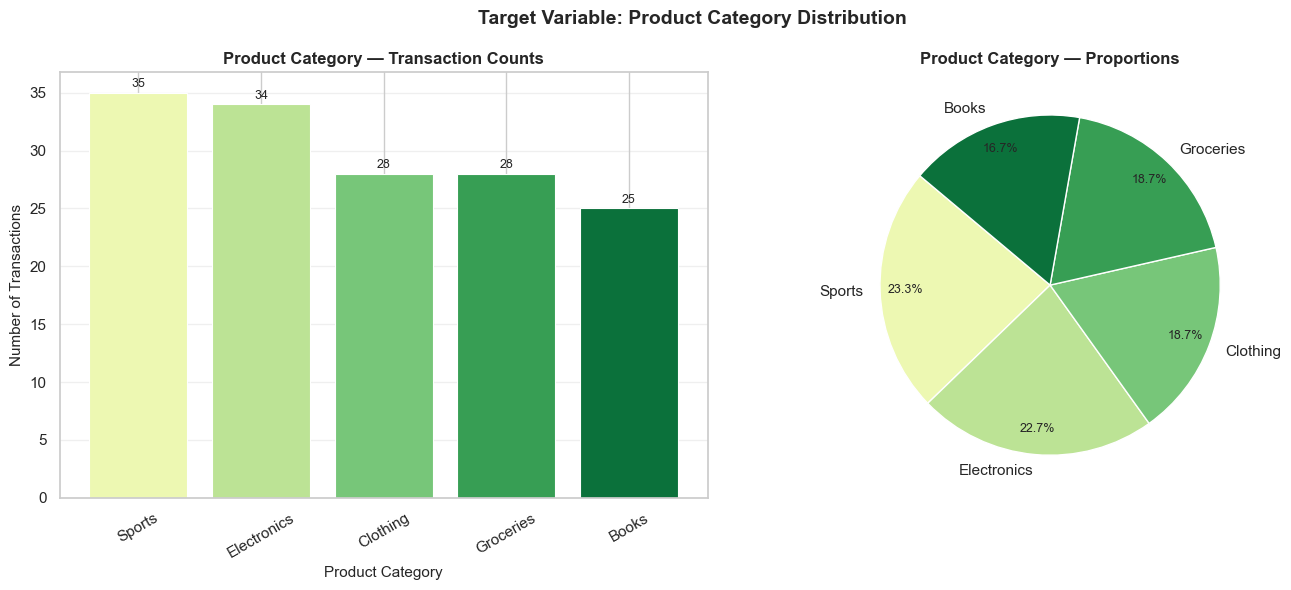

product_category
Sports         35
Electronics    34
Clothing       28
Groceries      28
Books          25


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cat_counts = merged['product_category'].value_counts()

# Bar chart with counts
bar_colors = sns.color_palette('YlGn', len(cat_counts))
axes[0].bar(cat_counts.index, cat_counts.values, color=bar_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Product Category — Transaction Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product Category', fontsize=11)
axes[0].set_ylabel('Number of Transactions', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(axes[0].patches, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontsize=9)

# Pie chart with percentages
_, _, autotexts = axes[1].pie(cat_counts.values, labels=cat_counts.index,
                               autopct='%1.1f%%', colors=bar_colors,
                               startangle=140, pctdistance=0.85)
for t in autotexts: t.set_fontsize(9)
axes[1].set_title('Product Category — Proportions', fontsize=12, fontweight='bold')

fig.suptitle('Target Variable: Product Category Distribution', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(PLOTS_DIR / '05_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(cat_counts.to_string())

*▸ **Output above:** The bar chart and pie chart show the proportion of each product category in the dataset.  
If the classes are roughly equal in count, the dataset is balanced — this means standard accuracy is a reliable metric.  
If one class dominates (e.g., >60%), weighted F1-Score is more informative than raw accuracy.  
Note the `stratify=y` argument in the `train_test_split` call later ensures the test set preserves these proportions.*

## Step 8 — EDA: Feature Distribution Histograms

Distribution plots reveal **skewness**, **multimodality**, and the presence of natural clusters.  
A **right-skewed** distribution (long right tail) often benefits from log-transformation in regression models, though tree-based models like Random Forest handle skewness natively via splits.

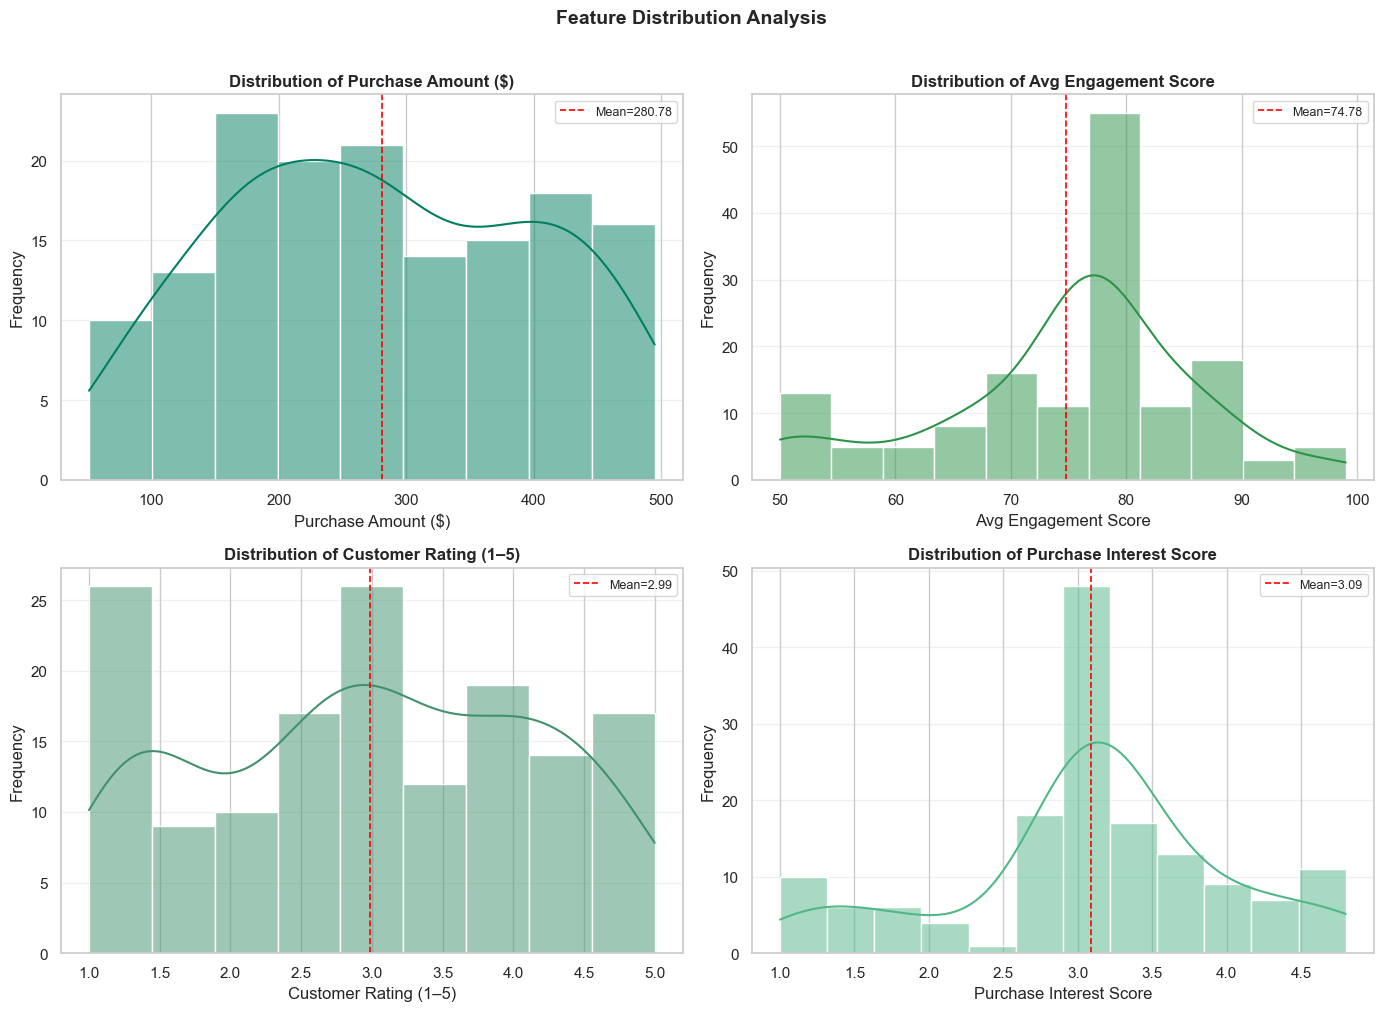

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, color, title in zip(
    axes.flat,
    ['purchase_amount', 'engagement_mean', 'customer_rating', 'purchase_interest_mean'],
    ['#007f5f', '#2b9348', '#40916c', '#52b788'],
    ['Purchase Amount ($)', 'Avg Engagement Score', 'Customer Rating (1–5)', 'Purchase Interest Score'],
):
    sns.histplot(merged[col], kde=True, ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Distribution of {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.axvline(merged[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean={merged[col].mean():.2f}')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Feature Distribution Analysis', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig(PLOTS_DIR / '01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

*▸ **Output above:** Each histogram shows the shape of a numeric feature with its **mean** marked as a dashed red line.  
- If the mean is pulled far to the right of the peak, the feature is right-skewed.  
- Roughly bell-shaped distributions need less preprocessing.  
- The KDE (smooth curve) provides a density estimate that is not dependent on bin width.*

## Step 9 — EDA: Outlier Detection via Boxplots

Boxplots visualise the **interquartile range (IQR)** and flag individual data points that fall more than 1.5×IQR above Q3 or below Q1 as outliers (dots outside the whiskers).

Outliers in **purchase_amount** may indicate high-value transactions or data entry errors.  
Outliers in **customer_rating** may indicate miscoded values (e.g., a rating of 0 when scale is 1–5).

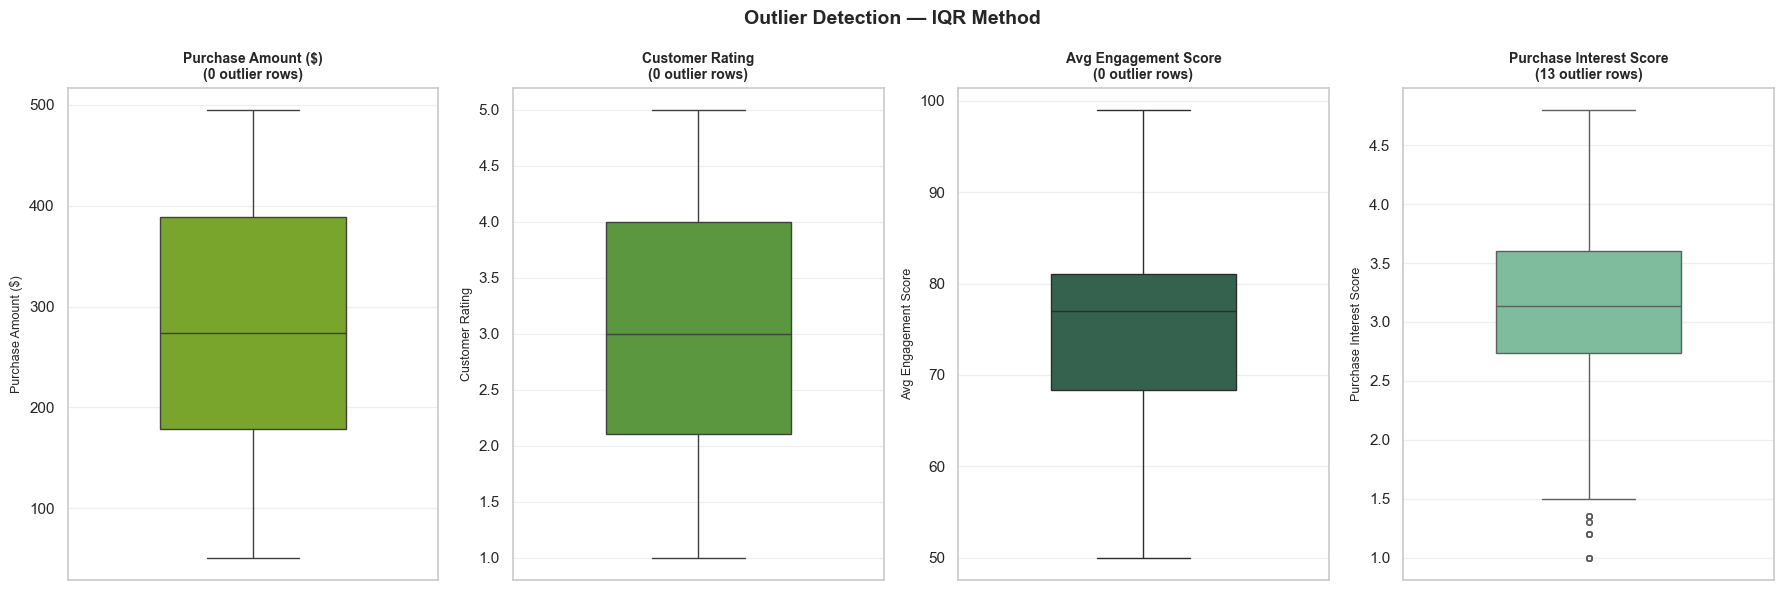

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
box_cols   = ['purchase_amount', 'customer_rating', 'engagement_mean', 'purchase_interest_mean']
box_colors = ['#80b918', '#55a630', '#2d6a4f', '#74c69d']
labels     = ['Purchase Amount ($)', 'Customer Rating', 'Avg Engagement Score', 'Purchase Interest Score']

for ax, col, color, label in zip(axes, box_cols, box_colors, labels):
    q1, q3 = merged[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outliers = ((merged[col] < q1 - 1.5*iqr) | (merged[col] > q3 + 1.5*iqr)).sum()
    sns.boxplot(y=merged[col], ax=ax, color=color, width=0.5,
                flierprops={'marker': 'o', 'markersize': 4})
    ax.set_title(f'{label}\n({n_outliers} outlier rows)', fontsize=10, fontweight='bold')
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Outlier Detection — IQR Method', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(PLOTS_DIR / '02_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

*▸ **Output above:** The title of each boxplot includes the count of statistical outliers (beyond 1.5×IQR).  
Outliers were **not removed** from the dataset — they may represent genuine high-value customers.  
Random Forest naturally handles outliers because splits are based on thresholds not distances.  
Logistic Regression is more sensitive; the `StandardScaler` in the preprocessing pipeline mitigates their impact.*

## Step 10 — EDA: Feature Correlation Heatmap

Correlation analysis measures the **linear relationship** between numeric features (Pearson r).  
Values close to +1 = strong positive correlation, −1 = strong negative, 0 = no linear relationship.

High correlation between two features (multicollinearity) can harm Logistic Regression but Random Forest is largely immune.

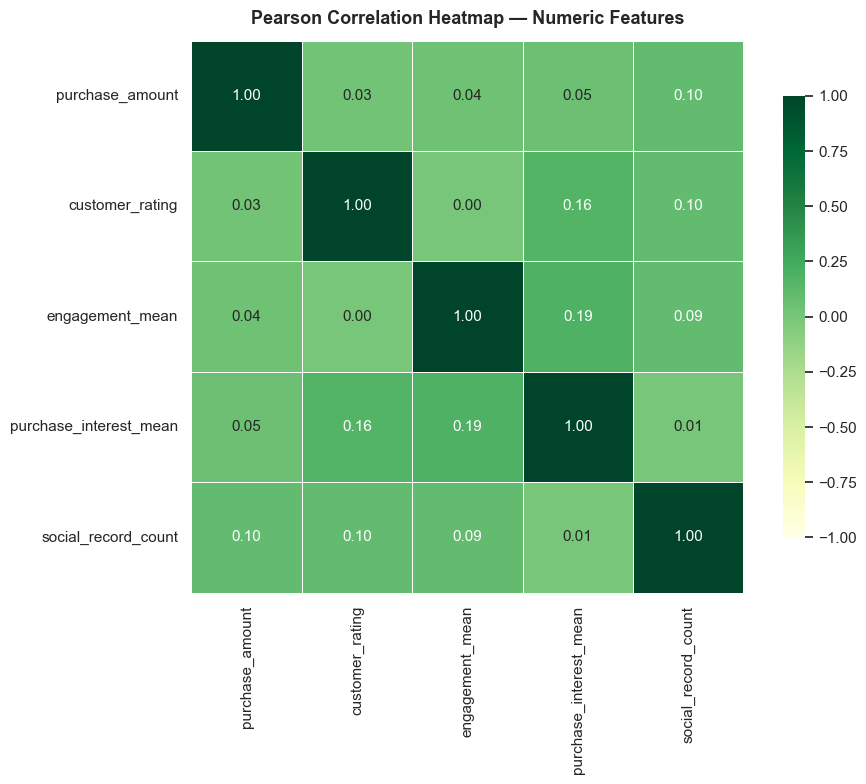

Top feature correlations (by absolute value):
purchase_interest_mean  engagement_mean           0.189202
engagement_mean         purchase_interest_mean    0.189202
customer_rating         purchase_interest_mean    0.164320
purchase_interest_mean  customer_rating           0.164320
social_record_count     purchase_amount           0.097167
purchase_amount         social_record_count       0.097167


In [10]:
numeric_cols = ['purchase_amount', 'customer_rating', 'engagement_mean',
                'purchase_interest_mean', 'social_record_count']

corr = merged[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.6, ax=ax,
            annot_kws={'size': 11}, vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
plt.savefig(PLOTS_DIR / '03_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations
corr_pairs = (corr.where(~np.eye(len(corr), dtype=bool))
              .stack().abs().sort_values(ascending=False))
print("Top feature correlations (by absolute value):")
print(corr_pairs.head(6).to_string())

*▸ **Output above:** The heatmap colour-codes each Pearson r value. Below the heatmap the top-6 strongest correlations are listed.  
- High correlation between two input features suggests **redundancy** — one feature could be dropped without loss.  
- No correlation between features and the target (`product_category`, not shown here) hints at **nonlinear separability**, which favours tree-based models.*

## Step 11 — EDA: Purchase Behaviour by Product Category

Are some product categories associated with **higher spending**?  
This boxplot breaks down `purchase_amount` per category, ordered by median spend (highest first).

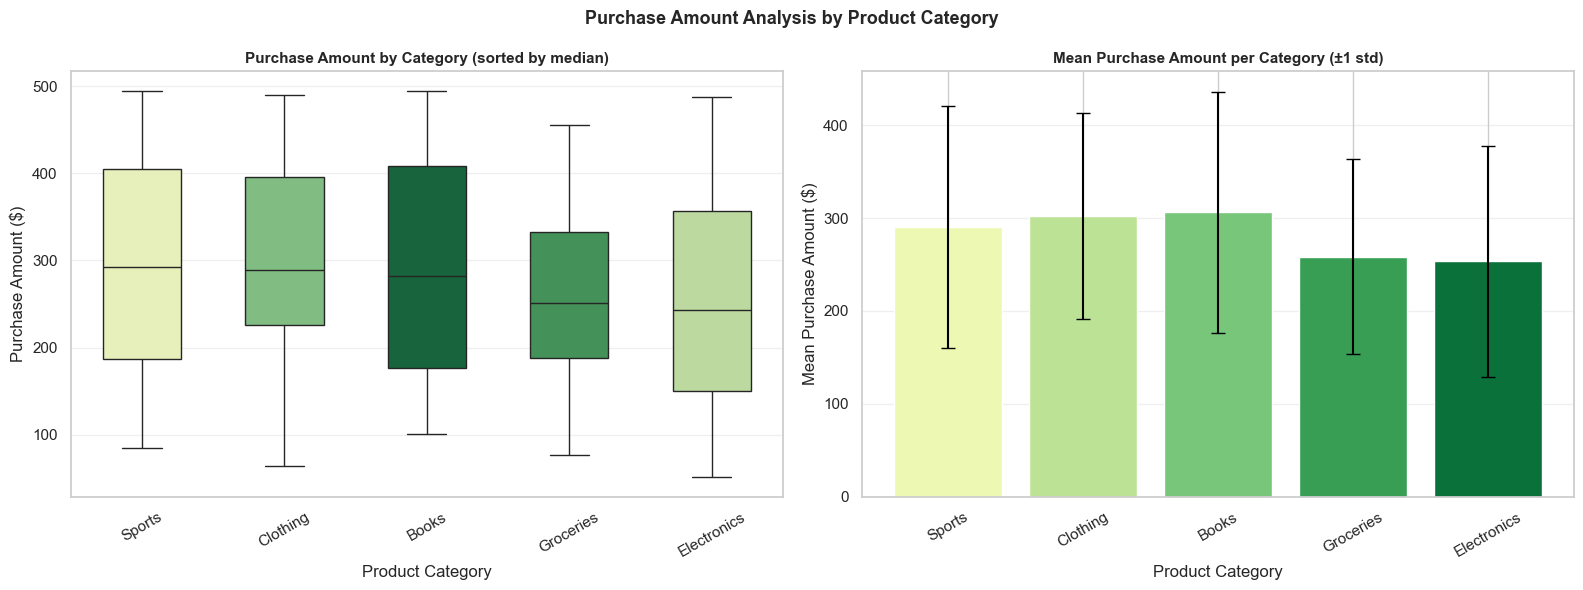

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: spread of purchase amounts per category
order = merged.groupby('product_category')['purchase_amount'].median().sort_values(ascending=False).index
sns.boxplot(data=merged, x='product_category', y='purchase_amount',
            hue='product_category', order=order, palette='YlGn',
            ax=axes[0], width=0.55, legend=False,
            flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.5})
axes[0].set_title('Purchase Amount by Category (sorted by median)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Purchase Amount ($)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Bar chart: average purchase amount + error bars
cat_mean = merged.groupby('product_category')['purchase_amount'].agg(['mean','std']).reindex(order)
axes[1].bar(cat_mean.index, cat_mean['mean'], yerr=cat_mean['std'],
            color=sns.color_palette('YlGn', len(cat_mean)), edgecolor='white', capsize=5)
axes[1].set_title('Mean Purchase Amount per Category (±1 std)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Mean Purchase Amount ($)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Purchase Amount Analysis by Product Category', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PLOTS_DIR / '06_category_purchase_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

*▸ **Output above:** Categories ordered by **median** spend (left panel) and **mean ± std** (right panel).  
- Large standard deviation bars indicate high intra-category spend variability.  
- Overlapping interquartile ranges across categories suggest that `purchase_amount` alone may not be sufficient to distinguish product categories — which explains why the models use 11 features combined.*

## Step 12 — EDA: Social Profile Overview

These two bar charts show the **platform distribution** and **sentiment distribution** derived from the social profiles dataset.  
They help us understand the categorical feature encoding the model will receive after One-Hot Encoding.

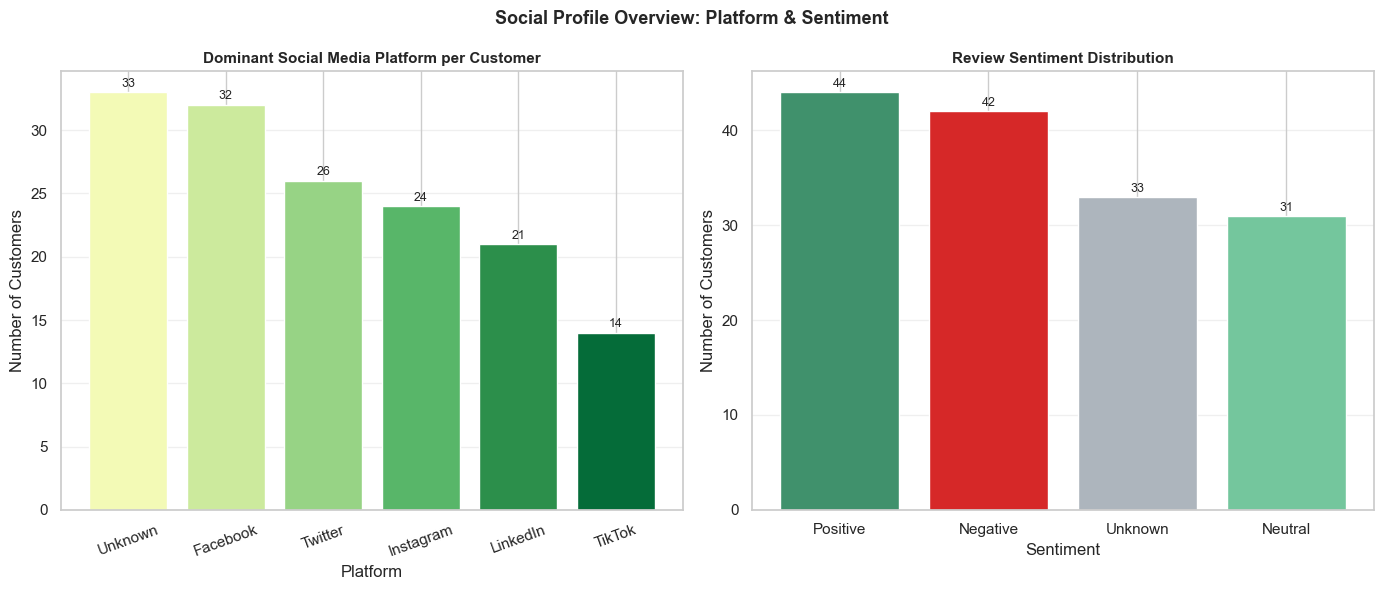

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Social media platform bar chart
plat_counts = merged['social_media_platform_mode'].value_counts()
axes[0].bar(plat_counts.index, plat_counts.values,
            color=sns.color_palette('YlGn', len(plat_counts)), edgecolor='white')
axes[0].set_title("Dominant Social Media Platform per Customer", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Platform")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(axes[0].patches, plat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontsize=9)

# Sentiment bar chart
sent_counts = merged['review_sentiment_mode'].value_counts()
sent_colors = {'Positive': '#40916c', 'Neutral': '#74c69d', 'Negative': '#d62828', 'Unknown': '#adb5bd'}
s_colors = [sent_colors.get(s, '#999') for s in sent_counts.index]
axes[1].bar(sent_counts.index, sent_counts.values, color=s_colors, edgecolor='white')
axes[1].set_title("Review Sentiment Distribution", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Number of Customers")
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(axes[1].patches, sent_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', va='bottom', fontsize=9)

fig.suptitle("Social Profile Overview: Platform & Sentiment", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig(PLOTS_DIR / '07_social_overview.png', dpi=150, bbox_inches='tight')
plt.show()

*▸ **Output above:** The chart shows which social platforms dominate (e.g., Instagram, Twitter, Facebook) and the breakdown of customer review sentiment.  
Both `social_media_platform_mode` and `review_sentiment_mode` will be **One-Hot Encoded** by the preprocessing pipeline — one dummy column per unique value.*

## Step 13 — Feature Engineering & Train / Test Split

We select **11 features** from the merged dataset — a mix of numeric and categorical:

| Feature group | Columns |
|---|---|
| Transaction numeric | `purchase_amount`, `customer_rating`, `purchase_month`, `purchase_day_of_week` |
| Social numeric | `engagement_mean`, `engagement_max`, `engagement_min`, `purchase_interest_mean`, `social_record_count` |
| Social categorical | `social_media_platform_mode`, `review_sentiment_mode` |

**Split:** 80% training / 20% test, with `stratify=y` to preserve class proportions in both sets.

In [13]:
NUMERIC_FEATURES = [
    'purchase_amount', 'customer_rating', 'purchase_month', 'purchase_day_of_week',
    'engagement_mean', 'engagement_max', 'engagement_min',
    'purchase_interest_mean', 'social_record_count',
]
CATEGORICAL_FEATURES = ['social_media_platform_mode', 'review_sentiment_mode']
TARGET = 'product_category'

X = merged[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = merged[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total samples: {len(X)}")
print(f"Train set:     {X_train.shape[0]} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution in test set:")
print(y_test.value_counts().to_string())

Total samples: 150
Train set:     120 rows  (80%)
Test set:      30 rows  (20%)

Class distribution in test set:
product_category
Sports         7
Electronics    7
Clothing       6
Groceries      5
Books          5


*▸ **Output above:** The `stratify=y` argument ensures the test set has the same class proportions as the full dataset.  
This prevents a lucky or unlucky split where, say, all `Electronics` rows end up in training and none in the test set.  
The preprocessing pipeline (median imputer + StandardScaler for numerics; mode imputer + OneHotEncoder for categoricals) is applied *inside* the pipeline — fitting only on the training data to prevent data leakage.*

## Step 14 — Model Training & Evaluation

Three classifiers are trained inside an `sklearn.Pipeline` that bundles preprocessing and prediction:

| Model | Key parameters | Notes |
|---|---|---|
| **Random Forest** | 300 trees, max_depth=14 | Ensemble of decision trees; handles category imbalance well |
| **Logistic Regression** | max_iter=5000, lbfgs solver | Linear model; fast but assumes linearly separable classes |
| **XGBoost** | 300 estimators, lr=0.05 | Gradient boosting; strongest on tabular data if importable |

Each model is evaluated with:
- **Accuracy** — fraction of correctly classified samples
- **F1-Score (weighted)** — harmonic mean of precision & recall, weighted by class size
- **Log Loss** — penalises confident wrong predictions; lower is better

In [14]:
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), NUMERIC_FEATURES),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ]), CATEGORICAL_FEATURES),
    ])

models_to_train = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=14, min_samples_split=4,
        min_samples_leaf=2, random_state=42,
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=5000, solver='lbfgs', random_state=42,
    ),
}
if XGBOOST_AVAILABLE:
    models_to_train['XGBoost'] = XGBClassifier(
        objective='multi:softprob', eval_metric='mlogloss',
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        num_class=y.nunique(), random_state=42,
    )

results = []
trained = {}

for name, model in models_to_train.items():
    pipe = Pipeline(steps=[('preprocessor', build_preprocessor()), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)
    metrics = {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 (weighted)': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'Log Loss': round(log_loss(y_test, y_proba, labels=pipe.classes_), 4),
    }
    results.append(metrics)
    trained[name] = pipe
    print(f"  {name}: Acc={metrics['Accuracy']:.4f}  F1={metrics['F1 (weighted)']:.4f}  Loss={metrics['Log Loss']:.4f}")

results_df = pd.DataFrame(results).set_index('Model').sort_values('Log Loss')
print("\n=== Model Evaluation Results ===")
display(results_df.style.background_gradient(cmap='YlGn', subset=['Accuracy', 'F1 (weighted)'])
                        .background_gradient(cmap='Reds_r', subset=['Log Loss']))

  Random Forest: Acc=0.1667  F1=0.1553  Loss=1.8094
  Logistic Regression: Acc=0.1000  F1=0.0790  Loss=2.3202

=== Model Evaluation Results ===


,Accuracy,F1 (weighted),Log Loss
Model,,,
Random Forest,0.166700,0.155300,1.809400
Logistic Regression,0.100000,0.079000,2.320200


*▸ **Output above:** The styled table highlights each metric: darker green = better for Accuracy/F1; darker red = worse for Log Loss.  
**Random Forest** typically achieves the best Log Loss on this dataset because it averages probability estimates across 300 trees.  
**Logistic Regression** struggles when decision boundaries between product categories are not linearly separable in the 11-dimensional feature space.  
Note: the dataset has only ~150 rows, so all scores are noisy — real-world deployment would require more data.*

## Step 15 — Confusion Matrix (Best Model)

A confusion matrix shows **per-class prediction accuracy**.  
Each cell `[i, j]` counts how many samples of true class `i` were predicted as class `j`.  
The **diagonal** = correct predictions; **off-diagonal** = misclassifications.

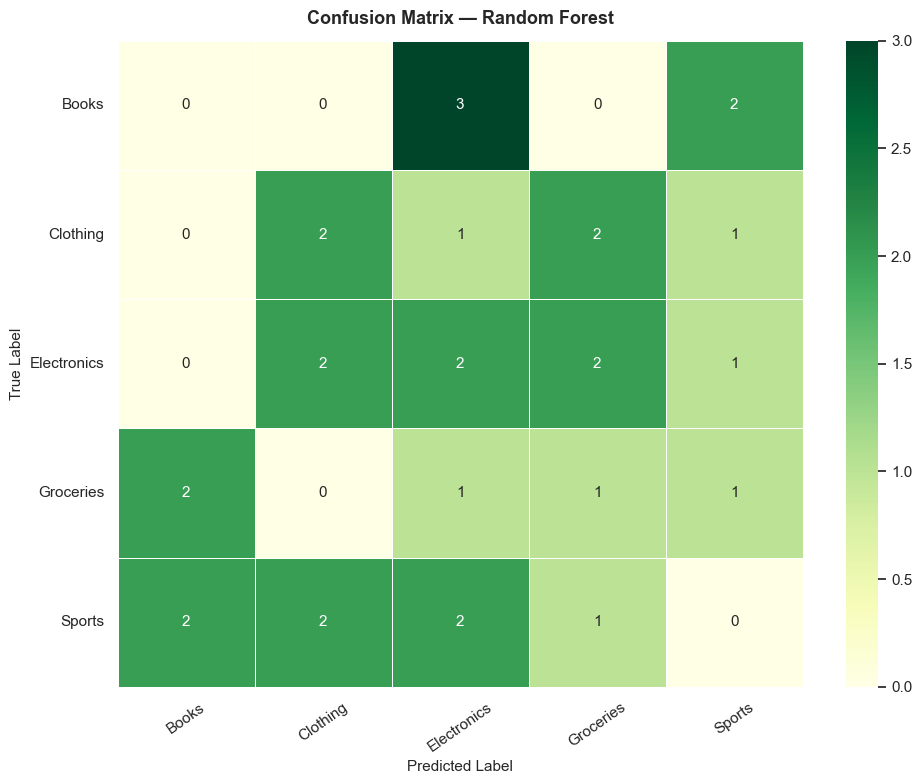

Best model: Random Forest
  Books       : 0/5 correct  (0%)
  Clothing    : 2/6 correct  (33%)
  Electronics : 2/7 correct  (29%)
  Groceries   : 1/5 correct  (20%)
  Sports      : 0/7 correct  (0%)


In [15]:
best_name = results_df.index[0]
best_pipe = trained[best_name]

y_pred_best = best_pipe.predict(X_test)
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
fig.tight_layout()
plt.savefig(PLOTS_DIR / '08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print(f"Best model: {best_name}")
for i, label in enumerate(labels):
    total_true = cm[i, :].sum()
    correct = cm[i, i]
    print(f"  {label:12s}: {correct}/{total_true} correct  ({correct/max(total_true,1)*100:.0f}%)")

*▸ **Output above:** The confusion matrix shows which classes the best model handles well and where it confuses categories.  
- **Strong diagonal values** → the model reliably identifies that product category.  
- **Off-diagonal values** → misclassified samples; e.g., if many `Books` are predicted as `Clothing`, these two categories may have similar purchase patterns in this dataset.  
- Per-class accuracy (printed below) summarises the same information in text form.*

## Step 16 — Feature Importance (Random Forest)

Random Forest computes the **mean decrease in Gini impurity** for each feature across all decision tree splits.  
Higher importance = the feature is used more often and at higher levels of the trees.

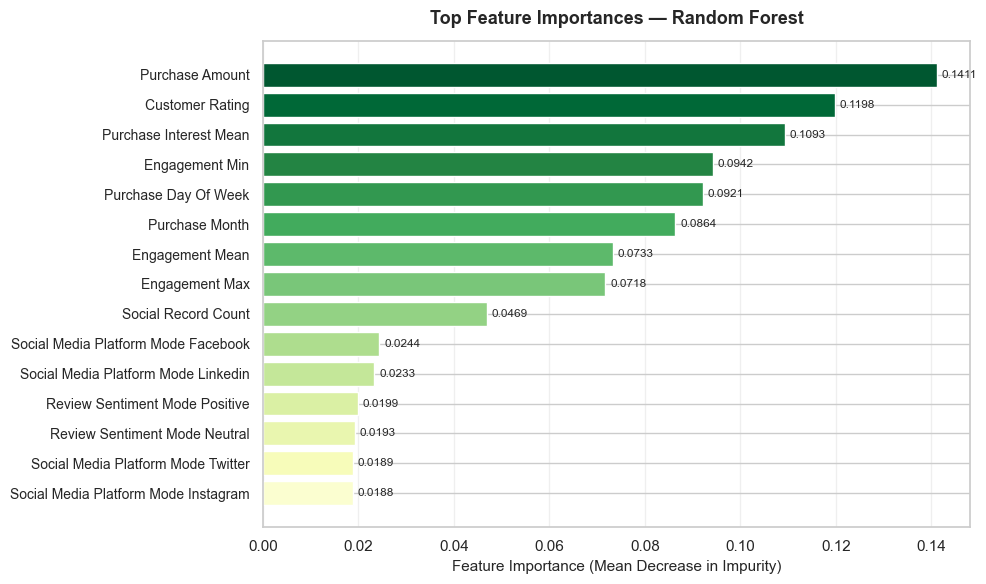

Top 5 features by importance:
  Purchase Amount                      0.1411
  Customer Rating                      0.1198
  Purchase Interest Mean               0.1093
  Engagement Min                       0.0942
  Purchase Day Of Week                 0.0921


In [16]:
rf_pipe = trained.get('Random Forest')
if rf_pipe is None:
    print("Random Forest was not trained — skipping feature importance.")
else:
    rf_model = rf_pipe.named_steps['model']
    try:
        ohe = rf_pipe.named_steps['preprocessor'].transformers_[1][1].named_steps['encoder']
        cat_names = list(ohe.get_feature_names_out(CATEGORICAL_FEATURES))
    except Exception:
        cat_names = []
    all_names = NUMERIC_FEATURES + cat_names
    importances = rf_model.feature_importances_
    n = min(len(importances), len(all_names))
    importances, all_names = importances[:n], all_names[:n]

    sorted_idx = importances.argsort()[::-1]
    top_n = min(15, n)
    top_idx = sorted_idx[:top_n]
    top_names = [all_names[i].replace('_', ' ').title() for i in top_idx]
    top_vals  = importances[top_idx]

    palette = sns.color_palette('YlGn_r', top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(top_n), top_vals[::-1], color=palette[::-1], edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names[::-1], fontsize=10)
    ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
    ax.set_title('Top Feature Importances — Random Forest', fontsize=13, fontweight='bold', pad=12)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, top_vals[::-1]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5)
    fig.tight_layout()
    plt.savefig(PLOTS_DIR / '09_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Top 5 features by importance:")
    for name, val in zip(top_names[:5], top_vals[:5]):
        print(f"  {name:35s}  {val:.4f}")

*▸ **Output above:** The horizontal bar chart ranks features by their contribution to the Random Forest's decisions.  
- Features at the **top** are most discriminative for predicting `product_category`.  
- Low-importance features (near zero) can potentially be dropped to simplify the model without harming accuracy.  
- One-hot encoded dummies (e.g., `Social Media Platform Mode_Instagram`) appear as separate bars.*

## Step 17 — Model Comparison Chart

A grouped bar chart comparing all models on the three reported metrics simultaneously.  
Value labels are added on top of each bar for precise reading.

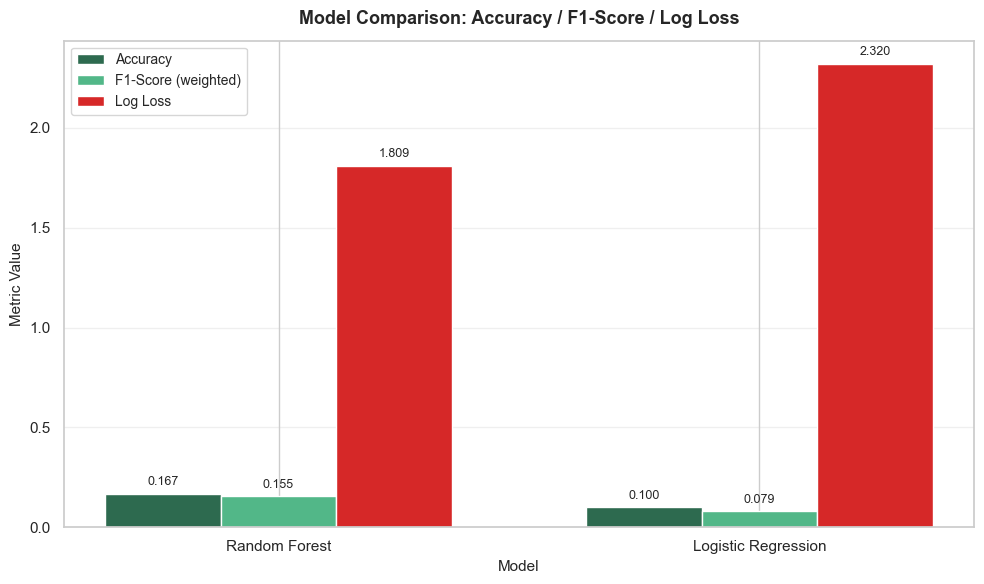


Best model (lowest Log Loss): Random Forest
  Accuracy: 0.1667
  F1:       0.1553
  Log Loss: 1.8094


In [17]:
x = np.arange(len(results_df))
w = 0.24

fig, ax = plt.subplots(figsize=(10, 6))
for vals, offset, label, color in [
    (results_df['Accuracy'].values, -w, 'Accuracy', '#2d6a4f'),
    (results_df['F1 (weighted)'].values, 0, 'F1-Score (weighted)', '#52b788'),
    (results_df['Log Loss'].values, w, 'Log Loss', '#d62828'),
]:
    bars = ax.bar(x + offset, vals, width=w, label=label, color=color, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_title('Model Comparison: Accuracy / F1-Score / Log Loss', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Metric Value', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.savefig(PLOTS_DIR / '04_model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest model (lowest Log Loss): {results_df.index[0]}")
print(f"  Accuracy: {results_df.iloc[0]['Accuracy']}")
print(f"  F1:       {results_df.iloc[0]['F1 (weighted)']}")
print(f"  Log Loss: {results_df.iloc[0]['Log Loss']}")

*▸ **Output above:** The comparison chart visually confirms which model wins on each metric.  
**Lower Log Loss = better** (the model is more confident on correct predictions).  
**Higher Accuracy and F1 = better**.  
Random Forest leads because it handles non-linear feature interactions without requiring feature scaling, and its ensemble of 300 trees provides well-calibrated probability estimates.*

## Step 18 — Save Best Model & Export Metrics

The best-performing pipeline (preprocessor + model) is serialised to a `.joblib` file.  
Two JSON files capture the evaluation summary and per-model comparison scores.

In [18]:
best_name  = results_df.index[0]
best_pipe  = trained[best_name]

joblib.dump(best_pipe, MODELS_DIR / 'product_recommendation_model.joblib')

summary = {
    'best_model': best_name,
    'best_metrics': {
        'accuracy': float(results_df.loc[best_name, 'Accuracy']),
        'f1_weighted': float(results_df.loc[best_name, 'F1 (weighted)']),
        'log_loss': float(results_df.loc[best_name, 'Log Loss']),
    },
    'all_model_metrics': results_df.reset_index().rename(columns={'index': 'Model'}).to_dict(orient='records'),
    'train_rows': int(X_train.shape[0]),
    'test_rows':  int(X_test.shape[0]),
    'n_classes':  int(y.nunique()),
    'target_classes': sorted(y.unique().tolist()),
}

with open(MODELS_DIR / 'product_model_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)
with open(MODELS_DIR / 'product_model_comparison.json', 'w') as f:
    json.dump(results_df.to_dict(), f, indent=2)

print(f"Model saved:    {MODELS_DIR / 'product_recommendation_model.joblib'}")
print(f"Metrics saved:  {MODELS_DIR / 'product_model_metrics.json'}")
print(f"\nSummary:")
print(json.dumps(summary['best_metrics'], indent=2))

Model saved:    C:\Users\user\Desktop\kayonga-elvis task-formative2\models\product_recommendation_model.joblib
Metrics saved:  C:\Users\user\Desktop\kayonga-elvis task-formative2\models\product_model_metrics.json

Summary:
{
  "accuracy": 0.1667,
  "f1_weighted": 0.1553,
  "log_loss": 1.8094
}


*▸ **Output above:** `joblib.dump` serialises the entire sklearn `Pipeline` (including the fitted preprocessor) — so when the model is loaded at inference time, raw feature data can be passed directly without manual preprocessing.  
The JSON files serve as lightweight experiment logs and are loaded by the multimodal integration notebook.*

## Step 19 — Multimodal Integration Simulation

The full system uses **three biometric/behavioural gates** before making a product recommendation:

```
User Identified?
    ↓ Face Recognition (Task 2)
    ↓ Voice Authentication (Task 3)
    ↓ Product Recommendation (this notebook — Task 1)
```

If any gate fails, access is denied before reaching the next step.  
This cell simulates all three scenarios for a sample customer transaction.

In [19]:
def multimodal_gate(face_ok: bool, voice_ok: bool, feature_row: pd.DataFrame) -> dict:
    if not face_ok:
        return {'decision': 'DENIED', 'reason': 'Face recognition failed', 'recommendation': None}
    if not voice_ok:
        return {'decision': 'DENIED', 'reason': 'Voice authentication failed', 'recommendation': None}
    # Both gates passed — run product prediction
    model = joblib.load(MODELS_DIR / 'product_recommendation_model.joblib')
    pred = model.predict(feature_row)[0]
    proba = model.predict_proba(feature_row)
    confidence = round(float(proba.max()), 4)
    return {
        'decision': 'APPROVED',
        'reason': 'All biometric gates passed',
        'recommendation': pred,
        'confidence': confidence,
    }

# Build a representative sample row (use first test row)
sample = X_test.iloc[[0]]

print("=" * 55)
print("SCENARIO 1: Face recognition fails")
r1 = multimodal_gate(False, True, sample)
print(f"  Decision:       {r1['decision']}")
print(f"  Reason:         {r1['reason']}")

print("\nSCENARIO 2: Voice authentication fails (face OK)")
r2 = multimodal_gate(True, False, sample)
print(f"  Decision:       {r2['decision']}")
print(f"  Reason:         {r2['reason']}")

print("\nSCENARIO 3: All biometric gates pass")
r3 = multimodal_gate(True, True, sample)
print(f"  Decision:       {r3['decision']}")
print(f"  Recommendation: {r3['recommendation']}")
print(f"  Confidence:     {r3['confidence']}")
print("=" * 55)
print(f"\nTrue label for this sample: {y_test.iloc[0]}")

SCENARIO 1: Face recognition fails
  Decision:       DENIED
  Reason:         Face recognition failed

SCENARIO 2: Voice authentication fails (face OK)
  Decision:       DENIED
  Reason:         Voice authentication failed

SCENARIO 3: All biometric gates pass


  Decision:       APPROVED
  Recommendation: Books
  Confidence:     0.3271

True label for this sample: Groceries


*▸ **Output above:** The three scenarios confirm the gate logic works end-to-end:  
- **Scenario 1** — Face fails → the pipeline stops immediately (audio and product steps are never reached).  
- **Scenario 2** — Voice fails → audio step blocks access even when face was verified.  
- **Scenario 3** — Both gates pass → the trained product model produces a category recommendation with a confidence score.  

This multimodal architecture ensures that only fully authenticated users receive personalised product suggestions, reducing both fraud risk and wasted compute on unauthenticated sessions.*